# Greenland Ice Velocity Hagen Bræ tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021). We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to query and fetch the dataset from our [Thredds server](https://thredds.geus.dk/), which is where we store and operationally update the PROMICE Ice Velocity product. Specifically, we will use the example of Hagen Bræ in Northwest Greenland to look at:
1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
2. Constructing and computing a velocity time-series from a flowline

So first, let's import all the packages we will be using.

In [58]:
# For dataset loading and handling
import xarray as xr
import numpy as np

# For plotting
import matplotlib.pyplot as plt

# For filename fetching
from siphon.catalog import TDSCatalog
from datetime import datetime, timedelta
import re

## 1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
The PROMICE Ice Velocity product is available on the [GEUS Thredds server](https://thredds.geus.dk/) as a series of individual files representing each time step. First let's connect and fetch all files into a readable dataset using OpenDAP querying.

In [59]:
# Construct xml catalog
catalog_url = "https://thredds.geus.dk/thredds/catalog/IVdata/rotr/catalog.xml"
cat = TDSCatalog(catalog_url)

# Find OpenDAP file urls
urls = []
for name, ds in cat.datasets.items():
    if "OPENDAP" in ds.access_urls:
        urls.append(ds.access_urls["OPENDAP"])
print(f"Found {len(urls)} files")

# Print the latest 10 file names
urls[-10:]

Found 308 files


['https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251031_20251124.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251112_20251206.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251124_20251218.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251206_20251230.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251218_20260111.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251230_20260123.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260111_20260204.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260123_20260216.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260204_20260228.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260216_20260312.nc']

We now have a list of all the OpenDAP querable file URLs. These files all share the same spatial grid and work along a time coordinate, therefore we can safely combine them using Python's xarray package.

For this tutorial, let's extract the date range from the file URLs and only load files from the summer melt season (May to September) in 2025.

In [60]:
# Define start and end date
start = datetime(2025, 5, 1)
end = datetime(2025, 9, 1)

# Define function for extracting date range from file url
def extract_date_range(url):
    m = re.search(r'(\d{8})_(\d{8})\.nc$', url)
    if m:
        start_str, end_str = m.groups()
        s = datetime.strptime(start_str, "%Y%m%d")
        e = datetime.strptime(end_str, "%Y%m%d")
        return s, e
    else:
        return None, None

filtered_urls = []
for url in urls:
    s, e = extract_date_range(url)
    if s is None:
        continue
    # Include file if it overlaps target range
    if e >= start and s <= end:
        filtered_urls.append(url)

print("Files to load:")
for u in filtered_urls:
    print(u.split('/')[-1])


Files to load:
IV_ROTR_V5_20250410_20250504.nc
IV_ROTR_V5_20250422_20250516.nc
IV_ROTR_V5_20250504_20250528.nc
IV_ROTR_V5_20250516_20250609.nc
IV_ROTR_V5_20250528_20250621.nc
IV_ROTR_V5_20250609_20250703.nc
IV_ROTR_V5_20250621_20250715.nc
IV_ROTR_V5_20250703_20250727.nc
IV_ROTR_V5_20250715_20250808.nc
IV_ROTR_V5_20250727_20250820.nc
IV_ROTR_V5_20250808_20250901.nc
IV_ROTR_V5_20250820_20250913.nc
IV_ROTR_V5_20250901_20250925.nc


Right, we now have a list of file URLs that we can open them with xarray, extract the variables that we want, and then combine them all. Large queries over multiple time steps and big regions can often be costly in time and resources, so be wary of how many files you are working from and how large your region is.

Let's download all horizontal surface velocity magnitude variable and subset them to our region of interest.

In [79]:
# Define region of interest
x1=210000
x2=275000
y1=-880000
y2=-940000

# Create empty list for appending to
datasets=[]

# Try to open urls one at a time
for url in filtered_urls:
    name = url.split('/')[-1]
    print(f"Processing: {name}")
    try:
        ds=xr.open_dataset(url)

        # Select horizontal velocity magnitude and standard deviation variables
        ds_region = ds[["land_ice_surface_velocity_magnitude","land_ice_surface_velocity_magnitude_std"]].sel(

            # Subset to region
            x=slice(x1,x2),
            y=slice(y1,y2)

        # Force dataset fetching
        ).load()

        # Append to list
        datasets.append(ds_region)

        # Close connection to dataset
        ds.close()

    except Exception as e:
        print(f"Skipping {name} due to error {e}")
        continue

# Combine all datasets along the same coordinates (x,y)
# and disregard differences in dataset attributes
ds_combined = xr.combine_by_coords(datasets,
                                   combine_attrs='override')

ds_combined


Processing: IV_ROTR_V5_20250410_20250504.nc


Note:Caching=1


Processing: IV_ROTR_V5_20250422_20250516.nc


Note:Caching=1


Processing: IV_ROTR_V5_20250504_20250528.nc


...

Processing: IV_ROTR_V5_20250820_20250913.nc


Note:Caching=1


Processing: IV_ROTR_V5_20250901_20250925.nc


Note:Caching=1


<xarray.Dataset> Size: 10MB
Dimensions:                                  (time: 13, y: 301, x: 326)
Coordinates:
  * time                                     (time) datetime64[ns] 104B 2025-...
  * y                                        (y) float64 2kB -8.8e+05 ... -9....
  * x                                        (x) float64 3kB 2.1e+05 ... 2.75...
Data variables:
    land_ice_surface_velocity_magnitude      (time, y, x) float32 5MB 0.00225...
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 5MB 0.00488...
Attributes:
    Conventions:                     CF-1.5
    time_coverage_start:             2025-04-10
    time_coverage_end:               2025-05-04
    sensors_used:                    Sentinel-1A,Sentinel-1C
    institution:                     GEUS
    methods_used:                    Offset-tracking
    calibration_method:              None
    title:                           Greenland Ice Velocity from 2025-04-10 t...
    summary:                         Greenland Ice Velocity from Sentinel-1 o...
    product_version:                 1.0
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

We can visualise this the horizontal surface velocity magnitude by selecting the appropriate variable and plotting it. Let's create a velocity map of our region, using the average from all time steps.

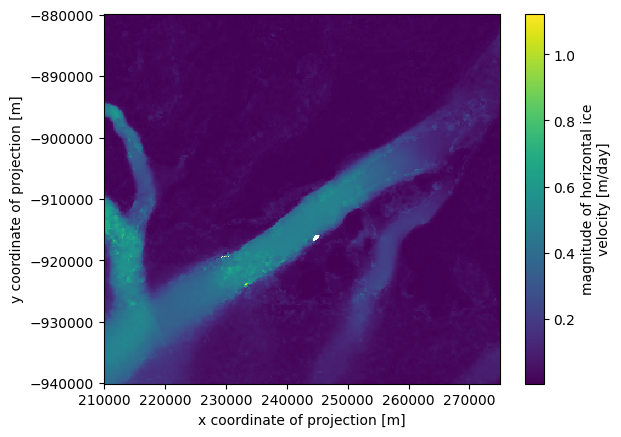

In [86]:
# Compute average horizontal velocity magnitude
region_average = ds_combined["land_ice_surface_velocity_magnitude"].mean(dim="time")

# Plot average horizontal velocity magnitude at Hagen Brae
plt.figure()
region_average.plot()
plt.show()


And here is the standard deviation for the velocity magnitude, which we can use to compute velocity magnitude uncertainty.

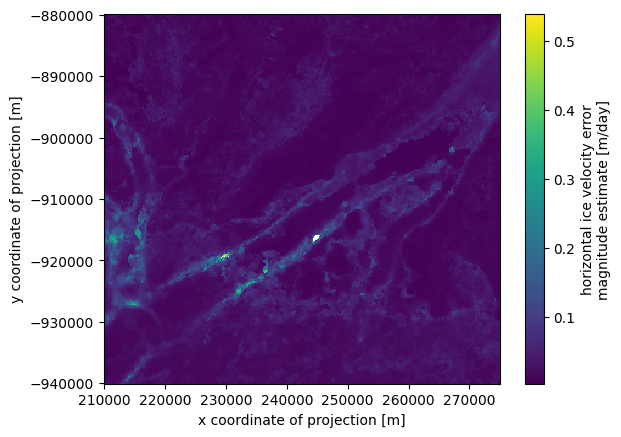

In [87]:
# Compute average horizontal velocity magnitude standard deviation
region_std_average = ds_combined["land_ice_surface_velocity_magnitude_std"].mean(dim="time")

# Plot average horizontal velocity magnitude SD
plt.figure()
region_std_average.plot()
plt.show()

## 2. Constructing and computing a velocity time-series from a flowline

Now let's generate a time-series of velocities across a flowline.

This flowline should be a one-dimensional line that represents a glacier's primary path of ice flow. We will firstly make a hypothetical flowline ourselves over the catchment of Hagen Bræ in Northeast Greenland. Then we will generate a velocity time-series over this flowline, capturing the average, minimum and maximum velocity.

Firstly, let's define our flowline as a set of predefined points. Then we will generate evenly spaced points along our flowline, and compute the cumulative distance along this. We'll plot it onto the first velocity field in our dataset, to see how it looks.

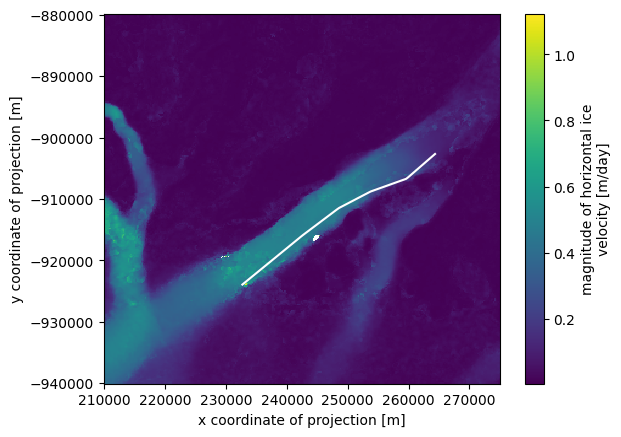

In [88]:
# Define flowline point locations
flowline_x = np.array([264352, 259672, 253754, 248511, 242556, 237624, 232692])
flowline_y = np.array([-902677, -906701, -908797, -911508, -915952, -919951, -923950])

# Calculate distance along flowline
dist_flowline = np.zeros(len(flowline_x))
for i in range(1, len(flowline_x)):
    dx = flowline_x[i] - flowline_x[i-1]
    dy = flowline_y[i] - flowline_y[i-1]
    dist_flowline[i] = dist_flowline[i-1] + np.sqrt(dx**2 + dy**2)

# Define number of points along flowline
n_points = 100
even_dist = np.linspace(0, dist_flowline[-1], n_points)

# Interpolate x, y at evenly spaced distances
x_even = np.interp(even_dist, dist_flowline, flowline_x)
y_even = np.interp(even_dist, dist_flowline, flowline_y)

# Plot horizontal velocity magnitude
plt.figure()
region_average.plot()

# Overlay point location
plt.plot(x_even, y_even, c="white")

# Show plot
plt.show()

We can now extract velocity values at the nearest grid points of each dataset using a nearest neighbour search across flattened grid coordinates in our velocity dataset.

In [90]:
flowline = ds_combined.interp(
    x=("points", x_even),
    y=("points", y_even),
    method="nearest"
)
flowline["land_ice_surface_velocity_magnitude"].shape

(13, 100)

And then we can plot our velocity profile along the flowline, specifically plotting time versus flowline velocity and standard deviation (as our uncertainty). We can also add a smoothed velocity if we wish to present longer-term velocity trends.

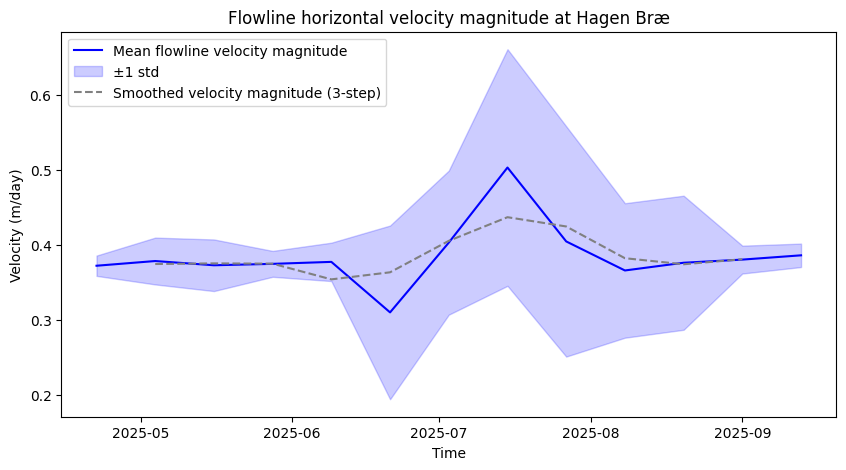

In [101]:
# Compute mean and ±1 std along flowline
flowline_mean = flowline["land_ice_surface_velocity_magnitude"].mean(dim="points")
flowline_std_mean = flowline["land_ice_surface_velocity_magnitude_std"].mean(dim="points")

# Plot average velocity with shaded std
plt.figure(figsize=(10,5))
plt.plot(flowline_mean.time, flowline_mean, label="Mean flowline velocity magnitude", color="blue")
plt.fill_between(
    flowline_mean.time,
    flowline_mean - flowline_std_mean,
    flowline_mean + flowline_std_mean,
    color="blue", alpha=0.2, label="±1 std"
)

# Plot smoothed velocity
flowline_avg_smooth = flowline_mean.rolling(time=3, center=True).mean()  # 3-time-step rolling average
plt.plot(flowline_mean.time, flowline_avg_smooth, '--', color='gray', label="Smoothed velocity magnitude (3-step)")

plt.title("Flowline horizontal velocity magnitude at Hagen Bræ")
plt.xlabel("Time")
plt.ylabel("Velocity (m/day)")
plt.legend()
plt.show()